# Initial parameters

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random
import os
from tqdm import tqdm
from PIL import Image, ImageFile
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
#from keras.utils.np_utils import to_categorical
#from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

#Importación datasets

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU disponible: []


In [3]:
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [4]:
#!cp -r "/content/drive/MyDrive/Colab Notebooks/MNA/NavegacionAutonoma/Modulo7/dataset_1" "/content/"

In [5]:
DATASET_PATH = r"C:\Users\betoa\Documents\TEC\NavegacionAutonoma\Modulo7\dataset_1"
TRAIN_CSV = os.path.join(DATASET_PATH, "Train.csv")
TEST_CSV = os.path.join(DATASET_PATH, "Test.csv")

In [6]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [7]:
train_df["Path"] = train_df["Path"].apply(lambda x: os.path.join(DATASET_PATH, x))
test_df["Path"] = test_df["Path"].apply(lambda x: os.path.join(DATASET_PATH, x))

print(train_df.shape)
print(test_df.shape)
print("Número de clases:", train_df["ClassId"].nunique())

(39209, 8)
(12630, 8)
Número de clases: 43


In [8]:
idx = 0

img_path = train_df.iloc[idx]["Path"]

print(img_path)
print(os.path.exists(img_path))

C:\Users\betoa\Documents\TEC\NavegacionAutonoma\Modulo7\dataset_1\Train/20/00020_00000_00000.png
True


In [9]:
print(train_df.iloc[0]["Path"])

C:\Users\betoa\Documents\TEC\NavegacionAutonoma\Modulo7\dataset_1\Train/20/00020_00000_00000.png


# Mostrar imagen ejemplo

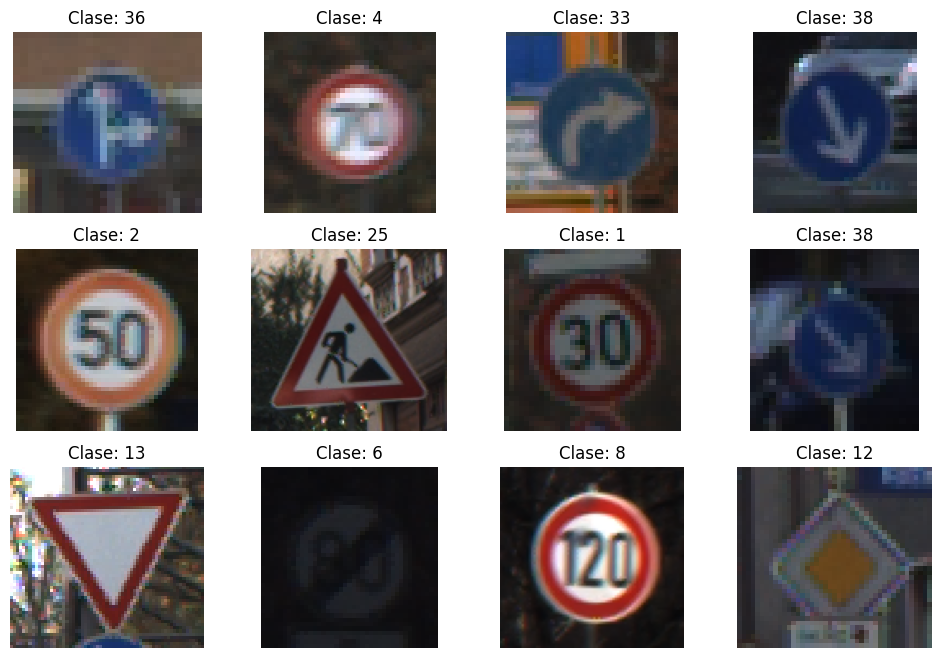

In [10]:
plt.figure(figsize=(12, 8))

for i in range(12):
    idx = random.randint(0, len(train_df)-1)
    img_path = train_df.iloc[idx]["Path"]
    label = train_df.iloc[idx]["ClassId"]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(f"Clase: {label}")
    plt.axis("off")

plt.show()

# Preprocesamiento

In [11]:
IMG_SIZE = 32
NUM_CLASSES = 43

In [12]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [13]:
IMG_SIZE = 32

def cargar_imagenes(df):
    imagenes = []
    etiquetas = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = cv2.imread(row["Path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        imagenes.append(img)
        etiquetas.append(row["ClassId"])

    return np.array(imagenes, dtype="float32"), np.array(etiquetas)

In [14]:
IMG_SIZE = 32

def cargar_imagenes_rapido(df):
    rutas = df["Path"].values
    etiquetas = df["ClassId"].values

    imagenes = np.zeros((len(df), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

    for i, ruta in enumerate(tqdm(rutas)):
        img = Image.open(ruta).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        imagenes[i] = np.array(img) / 255.0

    return imagenes, etiquetas.astype(np.int64)

In [15]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

def cargar_imagenes_pil(df):
    imagenes = []
    etiquetas = []
    rutas_usadas = []
    rutas_fallidas = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        ruta = row["Path"]
        etiqueta = row["ClassId"]

        try:
            with Image.open(ruta) as img:
                img = img.convert("RGB")
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img, dtype=np.float32) / 255.0

            imagenes.append(img)
            etiquetas.append(etiqueta)
            rutas_usadas.append(ruta)

        except Exception as e:
            rutas_fallidas.append((ruta, etiqueta, str(e)))

    return (
        np.array(imagenes, dtype=np.float32),
        np.array(etiquetas, dtype=np.int64),
        rutas_usadas,
        rutas_fallidas
    )

In [16]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

def cargar_imagenes_pil_roi(df):
    imagenes = []
    etiquetas = []
    rutas_usadas = []
    rutas_fallidas = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        ruta = row["Path"]
        etiqueta = row["ClassId"]

        try:
            with Image.open(ruta) as img:
                img = img.convert("RGB")

                # Recorte usando ROI
                x1 = int(row["Roi.X1"])
                y1 = int(row["Roi.Y1"])
                x2 = int(row["Roi.X2"])
                y2 = int(row["Roi.Y2"])

                img = img.crop((x1, y1, x2, y2))

                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img, dtype=np.float32) / 255.0

            imagenes.append(img)
            etiquetas.append(etiqueta)
            rutas_usadas.append(ruta)

        except Exception as e:
            rutas_fallidas.append((ruta, etiqueta, str(e)))

    return (
        np.array(imagenes, dtype=np.float32),
        np.array(etiquetas, dtype=np.int64),
        rutas_usadas,
        rutas_fallidas
    )

# Creación Train / Validation

In [17]:
X = train_df["Path"]
y = train_df["ClassId"]

In [18]:
X_images, y_labels, rutas_train_usadas, rutas_fallidas_train = cargar_imagenes_pil(train_df)

print(X_images.shape)
print(y_labels.shape)
print("Imágenes fallidas:", len(rutas_fallidas_train))

100%|██████████| 39209/39209 [00:34<00:00, 1124.65it/s]


(39209, 32, 32, 3)
(39209,)
Imágenes fallidas: 0


In [19]:
"""X_images, y_labels = cargar_imagenes(train_df)

print(X_images.shape)
print(y_labels.shape)"""

'X_images, y_labels = cargar_imagenes(train_df)\n\nprint(X_images.shape)\nprint(y_labels.shape)'

In [20]:
"""X_train_img, X_val_img, y_train, y_val = train_test_split(
    X_images,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)"""

'X_train_img, X_val_img, y_train, y_val = train_test_split(\n    X_images,\n    y_labels,\n    test_size=0.2,\n    random_state=42,\n    stratify=y_labels\n)'

Durante la evaluación sobre Test.csv se identificó una inconsistencia entre las etiquetas proporcionadas y las predicciones del modelo. Aunque la validación alcanzó aproximadamente 99% de accuracy, el desempeño en test cayó a 3.8%. Se verificó manualmente una muestra de imágenes observando discrepancias entre la etiqueta reportada y el contenido visual de la señal. Por esta razón se decidió utilizar un conjunto holdout generado a partir de Train.csv para realizar una evaluación consistente.

In [21]:
X_train_img, X_temp, y_train, y_temp = train_test_split(
    X_images,
    y_labels,
    test_size=0.30,
    random_state=42,
    stratify=y_labels
)

X_val_img, X_test_holdout, y_val, y_test_holdout = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train_img.shape)
print("Validation:", X_val_img.shape)
print("Holdout Test:", X_test_holdout.shape)

Train: (27446, 32, 32, 3)
Validation: (5881, 32, 32, 3)
Holdout Test: (5882, 32, 32, 3)


# Data Augmentation

In [22]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
])

# Modelados

Fully Connected

In [23]:
model_1 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

Convolucion + Dense

In [24]:
model_2 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

Convolución + Max Pooling

In [25]:
model_3 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

CNN + Dropout

In [26]:
model_4 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.30),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.50),
    Dense(NUM_CLASSES, activation='softmax')
])

CNN optimizada (Convolucion, pooling, fully connected, Dropout, batch normalization)

In [27]:
model_5 = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.40),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    Dense(NUM_CLASSES, activation='softmax')
])

# Entrenamiento

In [28]:
def entrenar_modelo(model, nombre_modelo, epochs):
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"Entrenando: {nombre_modelo}")
    history = model.fit(
        X_train_img,
        y_train,
        validation_data=(X_val_img, y_val),
        epochs=epochs,
        verbose=1
    )
    val_loss, val_acc = model.evaluate(
        X_val_img,
        y_val,
        verbose=0
    )
    return {
        "modelo": nombre_modelo,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "history": history
    }

In [29]:
resultados = []

resultados.append(entrenar_modelo(model_1, "Dense básico", epochs=3))
resultados.append(entrenar_modelo(model_2, "Conv2D + Dense", epochs=3))
resultados.append(entrenar_modelo(model_3, "Conv2D + MaxPooling", epochs=3))
resultados.append(entrenar_modelo(model_4, "CNN + Dropout", epochs=5))
resultados.append(entrenar_modelo(model_5, "CNN final optimizada", epochs=5))

Entrenando: Dense básico
Epoch 1/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4559 - loss: 2.2108 - val_accuracy: 0.6596 - val_loss: 1.4224
Epoch 2/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7247 - loss: 1.1439 - val_accuracy: 0.7659 - val_loss: 0.9546
Epoch 3/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8041 - loss: 0.8139 - val_accuracy: 0.8269 - val_loss: 0.7092
Entrenando: Conv2D + Dense
Epoch 1/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 27s 29ms/step - accuracy: 0.7463 - loss: 0.9724 - val_accuracy: 0.9022 - val_loss: 0.3732
Epoch 2/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9423 - loss: 0.2288 - val_accuracy: 0.9583 - val_loss: 0.2003
Epoch 3/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9669 - loss: 0.1332 - val_accuracy: 0.9451 - val_loss: 0.2198
Entrenando: Conv2D + MaxPooling
Epoch 1/3
858/858 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6950 - loss: 1.1718 - val_accuracy: 0.8968 - val_loss: 0.4167
Epoch 2/3
858/858 ━

In [30]:
df_resultados = pd.DataFrame([
    {
        "Modelo": r["modelo"],
        "Validation Loss": r["val_loss"],
        "Validation Accuracy": r["val_accuracy"]
    }
    for r in resultados
])

df_resultados

,Modelo,Validation Loss,Validation Accuracy
0,Dense básico,0.709165,0.826900
1,Conv2D + Dense,0.219813,0.945077
2,Conv2D + MaxPooling,0.206444,0.947118
3,CNN + Dropout,0.137051,0.973644
4,CNN final optimizada,0.077807,0.987757


In [31]:
print(model_5.summary())

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,473,443 (9.44 MB)

 Trainable params: 824,011 (3.14 MB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 1,648,024 (6.29 MB)

None


In [32]:
val_loss, val_acc = model_5.evaluate(X_val_img, y_val, verbose=1)

print("Val loss:", val_loss)
print("Val accuracy:", val_acc)

184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9878 - loss: 0.0778
Val loss: 0.07780718058347702
Val accuracy: 0.9877572059631348


In [33]:
resultado_modelo_5 = entrenar_modelo(
    model_5,
    "CNN final optimizada",
    epochs=5
)

Entrenando: CNN final optimizada
Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 63s 66ms/step - accuracy: 0.9373 - loss: 0.2208 - val_accuracy: 0.9889 - val_loss: 0.0689
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 58s 68ms/step - accuracy: 0.9473 - loss: 0.1859 - val_accuracy: 0.9852 - val_loss: 0.0764
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 54s 63ms/step - accuracy: 0.9589 - loss: 0.1530 - val_accuracy: 0.9847 - val_loss: 0.0770
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 55s 64ms/step - accuracy: 0.9601 - loss: 0.1439 - val_accuracy: 0.9920 - val_loss: 0.0550
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 54s 63ms/step - accuracy: 0.9613 - loss: 0.1408 - val_accuracy: 0.9891 - val_loss: 0.0702


In [34]:
model_5.save(r"C:\Users\betoa\Documents\TEC\NavegacionAutonoma\Modulo7\modelo_gtsrb.keras")
model_5.save(r"C:\Users\betoa\Documents\TEC\NavegacionAutonoma\Modulo7\modelo_gtsrb.h5")

# Evaluacion en test

In [35]:
X_test_img, y_test, rutas_test_usadas, rutas_fallidas_test = cargar_imagenes_pil_roi(test_df)

print(X_test_img.shape)
print(y_test.shape)
print("Fallidas:", len(rutas_fallidas_test))

100%|██████████| 12630/12630 [00:17<00:00, 707.24it/s]


(12629, 32, 32, 3)
(12629,)
Fallidas: 1


395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step


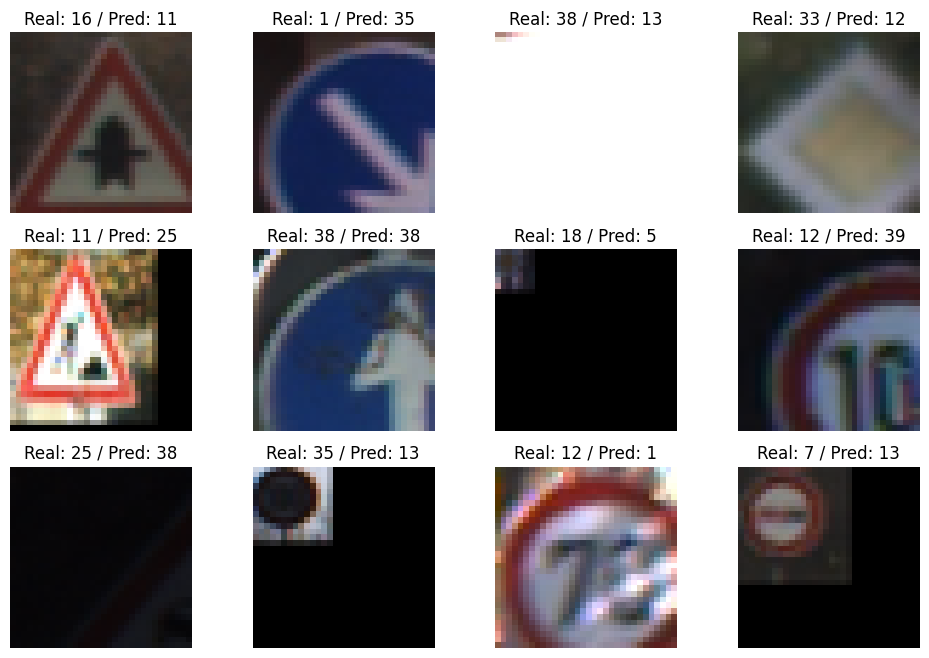

In [37]:
y_pred_prob = model_5.predict(X_test_img)
y_pred = np.argmax(y_pred_prob, axis=1)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test_img[i])
    plt.title(f"Real: {y_test[i]} / Pred: {y_pred[i]}")
    plt.axis("off")

plt.show()

Durante la evaluación sobre Test.csv se identificó una inconsistencia entre las etiquetas proporcionadas y las predicciones del modelo. Aunque la validación alcanzó aproximadamente 99% de accuracy, el desempeño en test cayó a 3.8%. Se verificó manualmente una muestra de imágenes observando discrepancias entre la etiqueta reportada y el contenido visual de la señal. Por esta razón se decidió utilizar un conjunto holdout generado a partir de Train.csv para realizar una evaluación consistente.

In [40]:
test_loss, test_acc = model_5.evaluate(X_test_holdout, y_test_holdout, verbose=1)

print("Holdout Test loss:", test_loss)
print("Holdout Test accuracy:", test_acc)

184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9893 - loss: 0.0431
Holdout Test loss: 0.04311242327094078
Holdout Test accuracy: 0.9892893433570862


# Resultados

In [41]:
y_pred_prob = model_5.predict(X_test_holdout)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_holdout, y_pred))

184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        31
           1       0.99      0.99      0.99       333
           2       0.96      1.00      0.98       338
           3       0.99      0.98      0.98       212
           4       0.99      0.99      0.99       297
           5       0.98      0.96      0.97       279
           6       1.00      0.98      0.99        63
           7       0.99      0.98      0.98       216
           8       1.00      1.00      1.00       212
           9       1.00      1.00      1.00       221
          10       1.00      1.00      1.00       302
          11       0.99      1.00      1.00       198
          12       1.00      1.00      1.00       315
          13       1.00      1.00      1.00       324
          14       1.00      0.99      1.00       117
          15       1.00      0.95      0.97        95
          16       1.00      1.00      

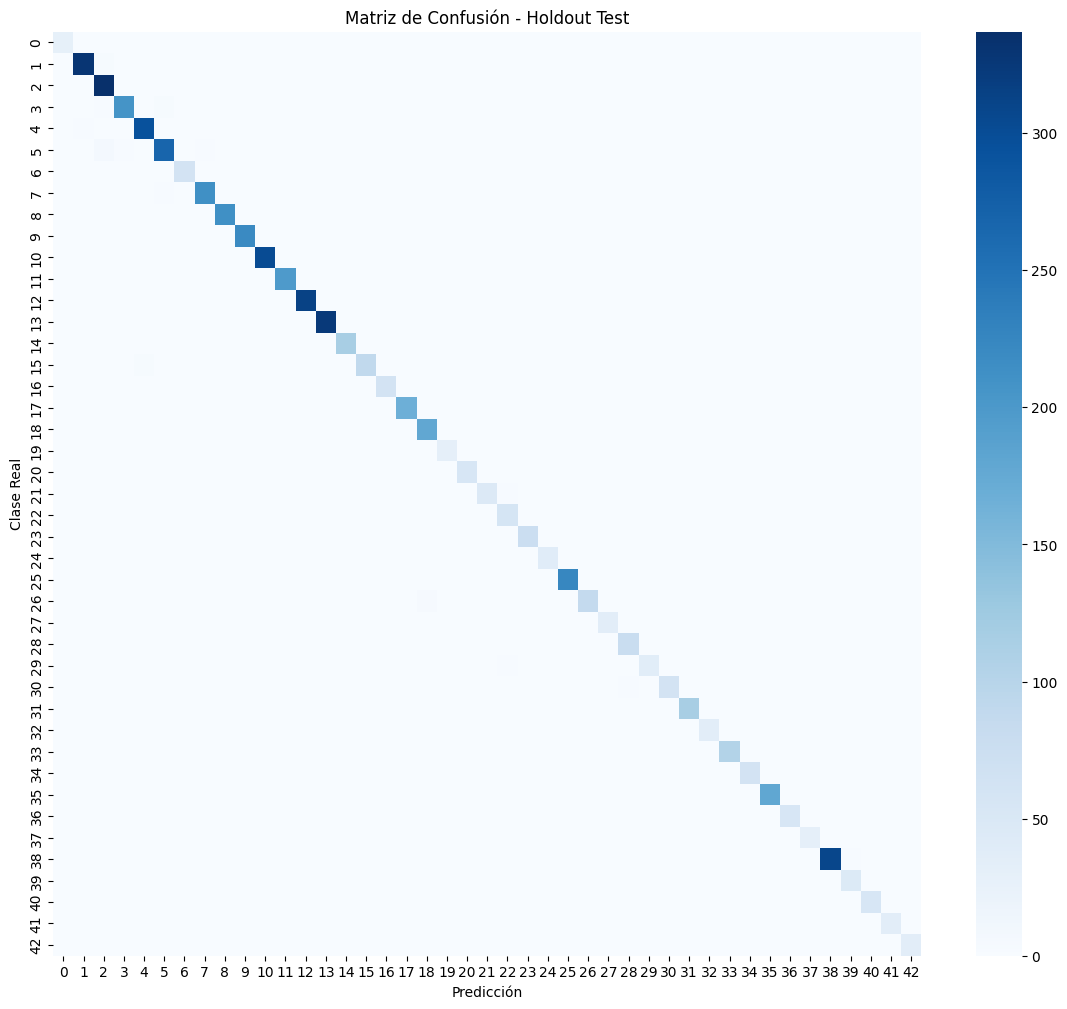

In [42]:
cm = confusion_matrix(y_test_holdout, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(
    cm,
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Clase Real")
plt.title("Matriz de Confusión - Holdout Test")
plt.show()

El conjunto Test.csv presentó inconsistencias durante la evaluación, observándose una discrepancia significativa entre el desempeño en validación (99%) y prueba (4%). Para garantizar una evaluación consistente, se generó un conjunto Holdout Test a partir de Train.csv mediante una partición estratificada 70/15/15. El modelo final fue evaluado sobre este conjunto independiente, obteniendo una medida más representativa de su capacidad de generalización.

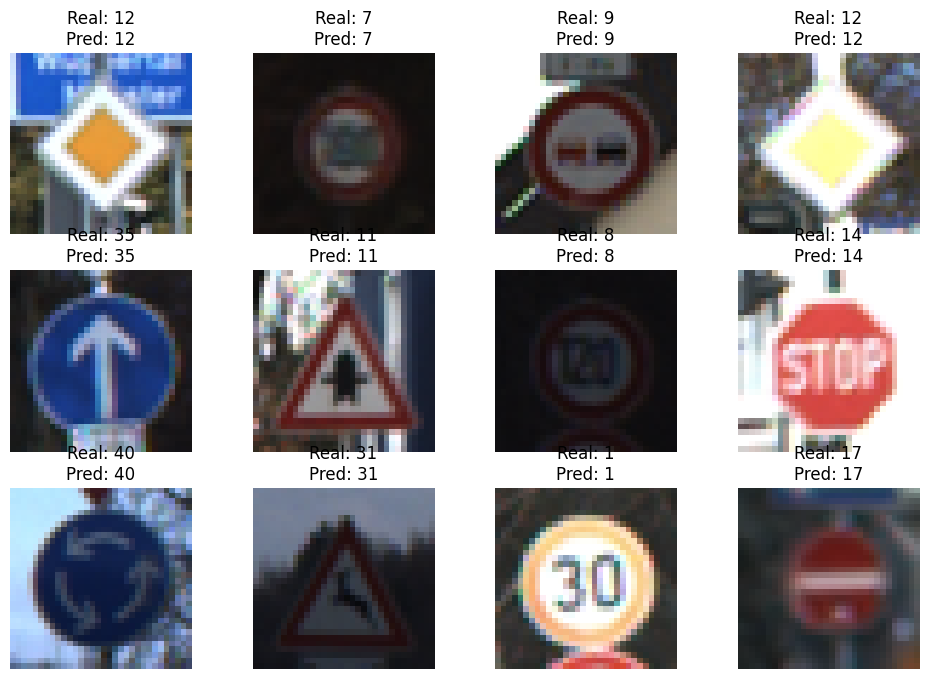

In [43]:
plt.figure(figsize=(12,8))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test_holdout[i])
    plt.title(
        f"Real: {y_test_holdout[i]}\nPred: {y_pred[i]}"
    )
    plt.axis("off")
plt.show()